# Bài tập Buổi 5 — Pipeline Machine Learning: EDA & Tiền xử lý trên Titanic

**Khóa học hè 2026 — Python & Machine Learning · ML IoT Lab, HCMUT**

---

## Bối cảnh

Bạn vừa nhận được dataset **Titanic** — danh sách hành khách và việc họ có sống sót sau thảm họa hay không.
Nhiệm vụ của bạn **không phải** huấn luyện mô hình, mà là hoàn thành **hai bước đầu và quan trọng nhất** của một dự án Machine Learning:

> **Khám phá dữ liệu (EDA) → Tiền xử lý dữ liệu.**

Đây là phần chiếm ~70–90% công sức thực tế của một dự án ML. Một mô hình mạnh không thể cứu một bộ dữ liệu kém chất lượng.

## Mục tiêu bài tập

Sau khi hoàn thành, bạn sẽ chứng minh được rằng mình có thể:

1. Thực hiện **EDA đầy đủ** trên một dataset thực tế: kiểm tra cấu trúc, giá trị thiếu, outlier, phân phối và tương quan.
2. **Trực quan hóa** dữ liệu và **rút ra nhận xét có căn cứ** (không chỉ vẽ hình cho đẹp).
3. Áp dụng **đúng kỹ thuật tiền xử lý** cho từng loại dữ liệu: xử lý missing, encoding, scaling.
4. Chia tập và xây pipeline tiền xử lý **không rò rỉ dữ liệu (data leakage)**.
5. Viết **nhận xét tổng hợp** về dữ liệu như một data analyst thực thụ.

## Yêu cầu nộp bài

- Hoàn thiện notebook này (điền vào tất cả các ô `# TODO` và các phần *"Trả lời:"*).
- Notebook phải **chạy được từ trên xuống dưới không lỗi** (Kernel → Restart & Run All).
- Nộp qua **GitHub**: tải repo mẫu → đưa lên repo cá nhân → làm bài và nộp trên đó.

## Tiêu chí chấm (10 điểm)

| Nội dung | Điểm |
|---|---|
| EDA đầy đủ (shape/info/missing/outlier) | 2.0 |
| Trực quan hóa + nhận xét cho mỗi biểu đồ | 2.0 |
| Xử lý missing & outlier hợp lý, có giải thích | 1.5 |
| Encoding & scaling đúng loại biến | 1.5 |
| Chia tập & tiền xử lý **không leakage** | 1.5 |
| Nhận xét tổng hợp về dữ liệu | 1.5 |

> **Lưu ý về liêm chính học thuật:** được tham khảo tài liệu, nhưng phải **tự viết code và tự hiểu**. Phần nhận xét phải là quan sát của chính bạn từ dữ liệu.

---


## 0. Chuẩn bị môi trường

Ô này đã viết sẵn — chạy để nạp thư viện. Nếu thiếu thư viện, cài bằng `pip install pandas numpy matplotlib seaborn scikit-learn`.

In [88]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, RobustScaler, StandardScaler

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")
np.random.seed(42)          # cố định ngẫu nhiên -> kết quả tái lập được
print("Sẵn sàng.")

Sẵn sàng.


## 1. Tải dữ liệu (đã cho)

Ô này đã viết sẵn. Dữ liệu được tải từ `seaborn`, có fallback tải từ Internet nếu cần.

In [89]:
try:
    df = sns.load_dataset("titanic")
    print("Đã tải từ seaborn.")
except Exception:
    url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    print("Đã tải từ URL.")
df.head()

Đã tải từ seaborn.


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


---
## Task 1 — Loại bỏ cột rò rỉ nhãn (data leakage) và cột dư thừa

### Mục đích
Trên slide đã học: **data leakage** là khi thông tin không được phép "rò" vào mô hình, khiến kết quả đẹp trên giấy nhưng vô dụng thực tế. Bản Titanic của seaborn chứa sẵn nhiều cột **rò rỉ nhãn** hoặc **trùng lặp**:

- `alive` (yes/no) — chính là `survived` viết bằng chữ ⇒ **rò rỉ target trực tiếp**. Để lại là mô hình "gian lận".
- `who`, `adult_male`, `class` — được suy ra từ `sex`, `age`, `pclass` (trùng thông tin).
- `deck` — thiếu quá nhiều (~77%).
- `embark_town` — trùng `embarked`; `alone` — suy ra từ `sibsp` + `parch`.

### Yêu cầu
1. In ra danh sách cột và tỷ lệ missing của **toàn bộ** dataframe (để thấy `deck` thiếu bao nhiêu).
2. Loại bỏ các cột rò rỉ / dư thừa ở trên, chỉ giữ lại:
   `survived, pclass, sex, age, sibsp, parch, fare, embarked`.
3. **Trả lời** (markdown ô dưới): vì sao để lại cột `alive` sẽ khiến mô hình đạt accuracy ~100% mà không thực sự học được gì?

### Gợi ý
- `df.isnull().mean()` cho tỷ lệ thiếu theo cột.
- `df.drop(columns=[...])` để bỏ cột.

In [90]:
# TODO 1a: in tỷ lệ missing của tất cả các cột
...
print("Tỷ lệ missing của từng cột (%):\n", df.isnull().mean() * 100)
# TODO 1b: bỏ các cột rò rỉ/dư thừa, gán lại vào biến df
leaky = ['alive', 'who', 'adult_male', 'class', 'deck', 'embark_town', 'alone']      # điền danh sách cột cần bỏ (chỉ những cột có trong df)
# df = df.drop(columns=...)
df = df.drop(columns=leaky)
# print("Các cột còn lại:", list(df.columns))
print("\nCác cột còn lại:", list(df.columns))

Tỷ lệ missing của từng cột (%):
 survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

Các cột còn lại: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked']


**Trả lời 1c (vì sao `alive` gây rò rỉ target):**

*(viết tại đây...)*
vì alive chứa thông tin giống biến survived nên nếu đưa cột này vào huấn luyện thì mô hình sẽ học trực tiếp kết quả từ đặc trưng này và bỏ qua các yếu tố khác dẫn đến hiện tượng data leakage. Lúc này, độ chính xác có thể đạt 100% nhưng mô hình thì hoàn toàn vô dụng.

---
## Task 2 — Quan sát tổng quan

### Mục đích
Trước khi phân tích sâu, phải nắm được "hình dạng" của dữ liệu: bao nhiêu mẫu, bao nhiêu đặc trưng, kiểu dữ liệu từng cột, và thống kê cơ bản. Đây là bước đầu tiên của mọi EDA.

### Yêu cầu
1. In **số dòng và số cột**; nêu rõ đâu là **biến mục tiêu (target)**.
2. Dùng `df.info()` để xem kiểu dữ liệu và số giá trị non-null.
3. Dùng `df.describe()` cho biến số và `df.describe(include="object")` (hoặc `"category"`) cho biến phân loại.
4. **Trả lời:** cột nào là biến **số**, cột nào là biến **phân loại**?

In [91]:
# TODO 2: shape, info, describe
...
print(f"Kích thước dữ liệu: {df.shape[0]} dòng, {df.shape[1]} cột.")
print("Biến mục tiêu (target) trong bài toán này là: 'survived'\n")
print("-" * 40)
print("thông tin dữ liệu:")
df.info()
print("-" * 40)
print("Thống kê mô tả(biến số):")
display(df.describe())
print("Thống kê mô tả(biến phân loại):")
display(df.describe(include=['object', 'category']))


Kích thước dữ liệu: 891 dòng, 8 cột.
Biến mục tiêu (target) trong bài toán này là: 'survived'

----------------------------------------
thông tin dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 8 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
dtypes: float64(2), int64(4), object(2)
memory usage: 55.8+ KB
----------------------------------------
Thống kê mô tả(biến số):


,survived,pclass,age,sibsp,parch,fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


Thống kê mô tả(biến phân loại):


,sex,embarked
count,891,889
unique,2,3
top,male,S
freq,577,644


**Trả lời 2 (biến số vs biến phân loại):**

*(viết tại đây...)*
- biến số: age, sibsp, parch, fare
- biến phân loại: survived, pclass, sex, embarked

---
## Task 3 — Missing Value: thống kê & đề xuất cách xử lý

### Mục đích
Mô hình học máy **không nhận trực tiếp giá trị NaN**. Nhưng cách xử lý phụ thuộc **tỷ lệ thiếu** và **vai trò của cột** — không có một cách đúng cho mọi trường hợp.

### Yêu cầu
1. Lập bảng: mỗi cột còn missing → **số lượng** và **phần trăm** thiếu.
2. Với **từng cột** còn thiếu, **đề xuất** cách xử lý và **giải thích ngắn gọn** (xóa / điền mean / điền median / điền mode / KNN...).

### Gợi ý
- Nhắc lại từ slide: `median` bền vững hơn `mean` khi có outlier; cột thiếu quá nhiều (>~60–70%) thường nên **bỏ**; biến phân loại thường điền **mode**.

In [92]:
# TODO 3: bảng missing (count + %)
...
missing_count = df.isnull().sum()
missing_percent = (df.isnull().mean() * 100).round(2)
missing_df = pd.DataFrame({
    'Số lượng (Count)': missing_count,
    'Tỷ lệ % (Percent)': missing_percent
})
missing_df = missing_df[missing_df['Số lượng (Count)'] > 0].sort_values(by='Tỷ lệ % (Percent)', ascending=False)
print("BẢNG THỐNG KÊ DỮ LIỆU THIẾU:")
display(missing_df)

BẢNG THỐNG KÊ DỮ LIỆU THIẾU:


,Số lượng (Count),Tỷ lệ % (Percent)
age,177,19.87
embarked,2,0.22


**Trả lời 3 (đề xuất xử lý cho từng cột thiếu):**

| Cột | % thiếu | Cách xử lý đề xuất | Lý do |
|---|---|---|---|
| age | 19.87% | Median | age là biến số có tỷ lệ thiếu khá lớn nên nếu điền bằng mean, giá trị có thể bị kéo lệch bởi các outlier. Median là đại lượng đo lường trung tâm bền vững hơn |
| embarked | 0.22% | Mode | embarked là biến phân loại nên ko thể dùng mean hay median, vì tỷ lệ thiếu nhỏ nên sử dụng mode an toàn hơn |

---
## Task 4 — Phát hiện Outlier & **ra quyết định**

### Mục đích
Outlier có thể là **lỗi nhập liệu** (cần xử lý) hoặc **hiện tượng thật** (cần giữ). Phát hiện thôi chưa đủ — một analyst giỏi phải **quyết định** làm gì và giải thích được.

### Yêu cầu
1. Trên hai cột `age` và `fare`, đếm số outlier bằng **cả hai** phương pháp: **IQR** và **Z-score** (ngưỡng |z| > 3).
2. **Trả lời:** với các outlier của `fare`, bạn **giữ lại hay loại bỏ**? Vì sao? (gợi ý: nghĩ xem vé đắt bất thường là lỗi hay là vé hạng nhất có thật).

### Gợi ý
- IQR: outlier là điểm ngoài khoảng `[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`.
- Z-score: `from scipy import stats; np.abs(stats.zscore(series.dropna()))`.

In [93]:
# TODO 4: đếm outlier theo IQR và Z-score cho 'age' và 'fare'
def dem_outlier_iqr(s):
    ...    # trả về số lượng outlier theo IQR
    s = s.dropna() 
    Q1 = s.quantile(0.25)
    Q3 = s.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return ((s < lower_bound) | (s > upper_bound)).sum()

def dem_outlier_zscore(s, nguong=3.0):
    ...    # trả về số lượng outlier theo Z-score
    s = s.dropna()
    z_scores = np.abs(stats.zscore(s))
    return (z_scores > nguong).sum()

# for col in ["age", "fare"]:
#     ...
print("kết quả đếm outlier:")
for col in ["age", "fare"]:
    print(f"--- Cột '{col}' ---")
    print(f"Số outlier theo IQR: {dem_outlier_iqr(df[col])}")
    print(f"Số outlier theo Z-score (|z| > 3): {dem_outlier_zscore(df[col])}\n")

kết quả đếm outlier:
--- Cột 'age' ---
Số outlier theo IQR: 11
Số outlier theo Z-score (|z| > 3): 2

--- Cột 'fare' ---
Số outlier theo IQR: 116
Số outlier theo Z-score (|z| > 3): 20



**Trả lời 4 (quyết định với outlier của `fare`):**

*(viết tại đây...)*
Giữ lại vì outlier trong trường hợp này không phải do lỗi nhập liệu nên nếu loại bỏ chúng thì sẽ làm mất đi thông tin của một nhóm hành khách quan trọng

---
## Task 5 — Trực quan hóa & nhận xét

### Mục đích
EDA là môn học về **nhìn** dữ liệu. Mỗi biểu đồ phải trả lời một câu hỏi và **đi kèm một nhận xét**. Vẽ mà không nhận xét thì không tính điểm.

### Yêu cầu — vẽ tối thiểu 4 loại biểu đồ, mỗi biểu đồ 1–2 câu nhận xét:
1. **Univariate — Histogram**: phân phối của `age` và `fare`. (Nhận xét: có lệch không? lệch trái hay phải?)
2. **Univariate — Boxplot**: `fare` theo nhóm `survived` hoặc `pclass`. (Nhận xét: outlier, trung vị.)
3. **Bivariate — Bar/Barplot**: **tỷ lệ sống sót** theo `sex` và theo `pclass`. (Nhận xét: nhóm nào sống nhiều hơn, chênh bao nhiêu %?)
4. **Multivariate — Heatmap**: ma trận tương quan giữa các biến số. (Nhận xét: cặp biến nào tương quan mạnh?)

### Gợi ý
- `sns.histplot`, `sns.boxplot`, `sns.barplot(data=df, x="sex", y="survived")` (barplot tự tính trung bình = tỷ lệ sống sót), `sns.heatmap(df.select_dtypes("number").corr(), annot=True)`.

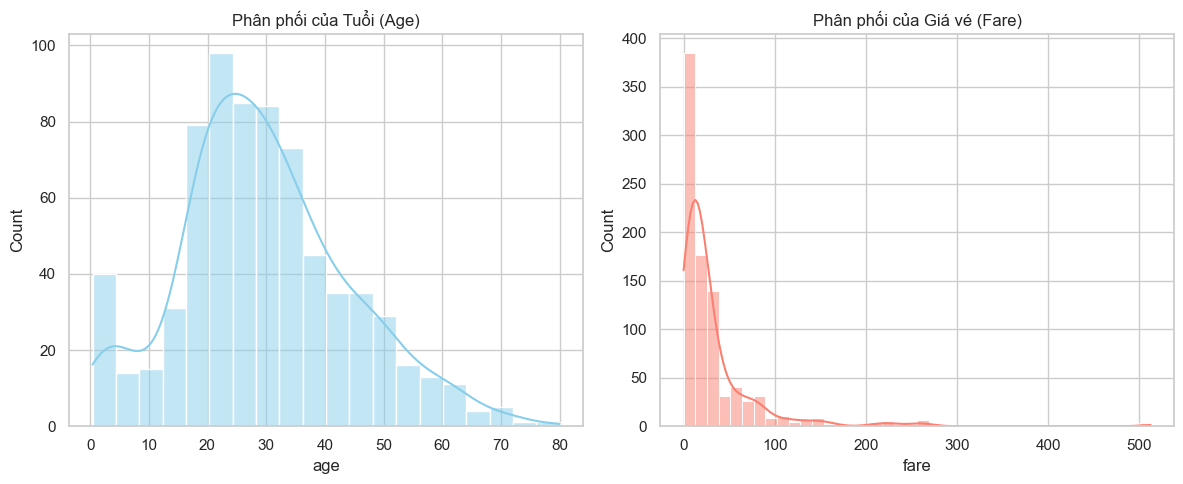

In [94]:
# TODO 5a: Histogram age & fare
...
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.histplot(data=df, x='age', kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Phân phối của Tuổi (Age)')

sns.histplot(data=df, x='fare', kde=True, bins=40, ax=axes[1], color='salmon')
axes[1].set_title('Phân phối của Giá vé (Fare)')

plt.tight_layout()
plt.show()

C:\Users\user\AppData\Local\Temp\ipykernel_30612\503983804.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')


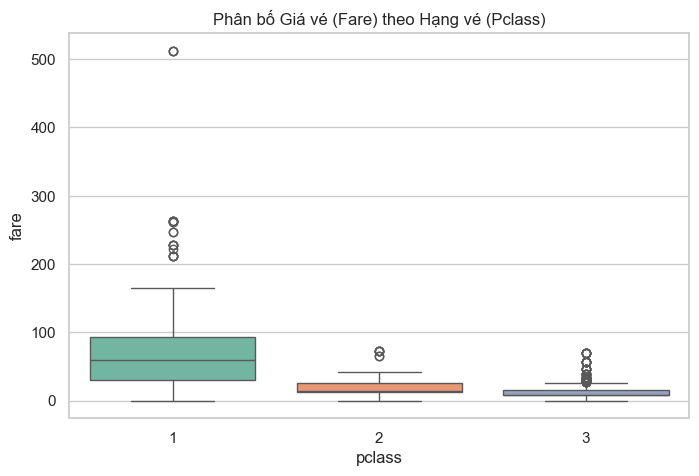

In [95]:
# TODO 5b: Boxplot fare theo survived hoặc pclass
...
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='pclass', y='fare', palette='Set2')
plt.title('Phân bố Giá vé (Fare) theo Hạng vé (Pclass)')
plt.show()

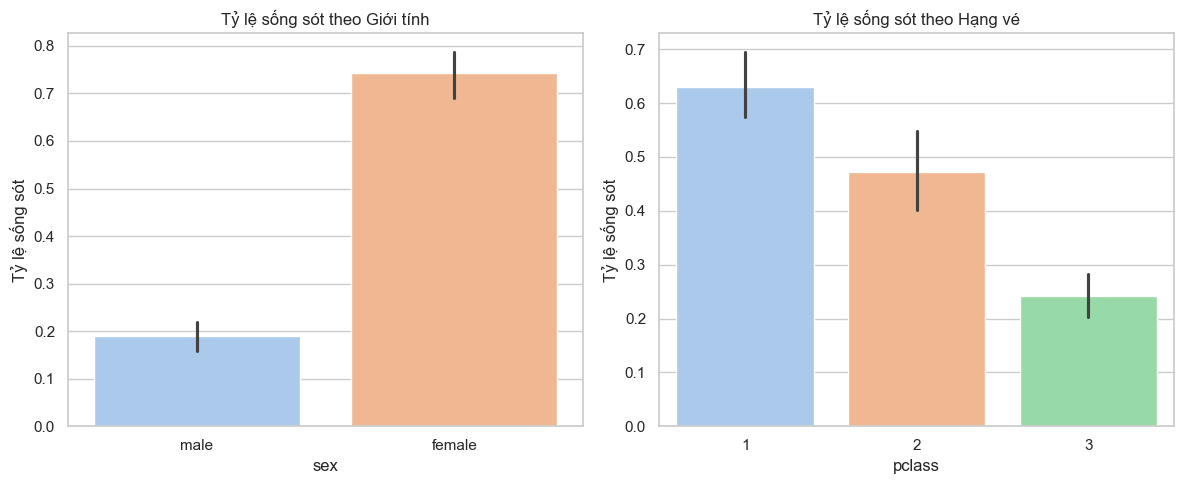

In [96]:
# TODO 5c: Barplot tỷ lệ sống sót theo sex và pclass
...
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.barplot(data=df, x='sex', y='survived', ax=axes[0], hue='sex', palette='pastel', legend=False)
axes[0].set_title('Tỷ lệ sống sót theo Giới tính')
axes[0].set_ylabel('Tỷ lệ sống sót')
sns.barplot(data=df, x='pclass', y='survived', ax=axes[1], hue='pclass', palette='pastel', legend=False)
axes[1].set_title('Tỷ lệ sống sót theo Hạng vé')
axes[1].set_ylabel('Tỷ lệ sống sót')

plt.tight_layout()
plt.show()

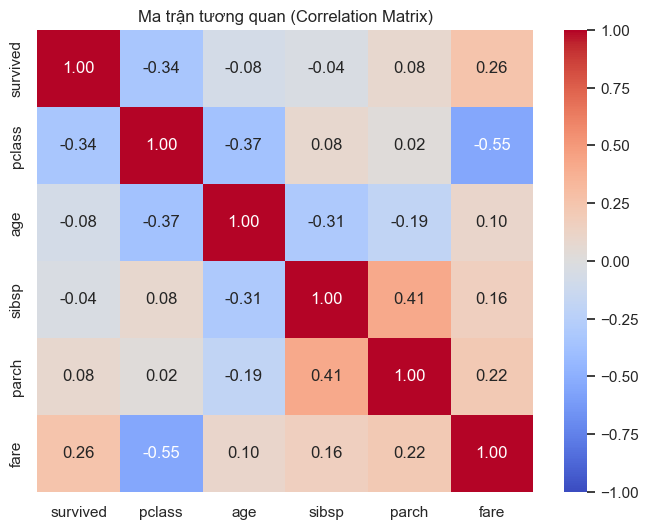

In [97]:
# TODO 5d: Heatmap correlation
...
plt.figure(figsize=(8, 6))
num_cols = df.select_dtypes(include=['number'])
corr_matrix = num_cols.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Ma trận tương quan (Correlation Matrix)')
plt.show()

**Nhận xét 5 (viết cho từng biểu đồ ở trên):**

- Histogram: Cột age có phân phối xấp xỉ chuẩn nhưng hơi lệch phải, cho thấy hành khách chủ yếu là thanh niên từ 20 đến 30 tuổi. Cột fare bị lệch phải cực kỳ mạnh, đại đa số hành khách mua vé giá rẻ, chỉ có một số rất ít hành khách mua vé giá cực kỳ cao.
- Boxplot: Khi xét fare theo pclass, ta thấy rõ sự phân cấp tài sản. Hạng 1 có mức giá trải dài, trung vị cao nhất và chứa những điểm outlier có giá trị lớn. Trong khi đó, hạng 2 và hạng 3 có trung vị rất thấp, hộp boxplot bị ép dẹp lại, chứng tỏ giá vé hạng này rất rẻ và ít có sự chênh lệch.
- Bar survival: Biểu đồ tỷ lệ sống sót cho thấy sự chênh lệch đáng kinh ngạc: Phụ nữ có tỷ lệ sống sót cực cao (trên 70%), trong khi nam giới chỉ ở mức dưới 20%. Tương tự, hạng vé cũng quyết định sinh tử: hành khách Hạng 1 sống sót nhiều nhất (khoảng 60%), Hạng 2 khoảng 47%, và Hạng 3 thấp nhất (dưới 25%).
- Heatmap: Ma trận tương quan chỉ ra hai cặp biến đáng chú ý nhất. Thứ nhất, pclass và fare có tương quan âm khá mạnh, điều này hiển nhiên vì hạng vé mang số càng nhỏ thì giá vé càng cao. Thứ hai, sibsp và parch có tương quan dương, cho thấy những người đi cùng anh chị em/vợ chồng thường cũng đi cùng cả cha mẹ/con cái. Các biến số độc lập khác không có tương quan trực tiếp mạnh mẽ tới biến mục tiêu survived.

---
## Task 6 — Chia tập **TRƯỚC** khi tiền xử lý (chống data leakage)

### Mục đích
Đây là điểm mấu chốt của buổi học. Mọi phép "học tham số" từ dữ liệu (median để điền, min/max/IQR để scale, danh mục để encode) **chỉ được học từ tập train**. Nếu học từ toàn bộ dữ liệu rồi mới chia, thông tin của tập test đã **rò rỉ** — điểm đánh giá sẽ ảo.

⇒ **Vì vậy phải chia tập TRƯỚC**, rồi mới xử lý.

### Yêu cầu
1. Tách `X` (đặc trưng) và `y` (`survived`).
2. Chia **train / validation / test** theo tỷ lệ khoảng **70 / 15 / 15**, có **`stratify=y`** để giữ nguyên tỷ lệ hai lớp.
3. In shape của 3 tập và **tỷ lệ sống sót** trong mỗi tập (để kiểm tra stratify hoạt động).

### Gợi ý
- Dùng `train_test_split` **hai lần**: lần 1 tách test (15%), lần 2 tách val từ phần còn lại.
- `stratify` nhận vào nhãn tương ứng ở mỗi lần chia.

In [98]:
# TODO 6: chia train/val/test có stratify
X = df.drop(columns=['survived'])
y = df['survived']

# X_tmp, X_test, y_tmp, y_test = train_test_split(...)
X_tmp, X_test, y_tmp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
# X_train, X_val, y_train, y_val = train_test_split(...)
X_train, X_val, y_train, y_val = train_test_split(X_tmp, y_tmp, test_size=(15/85), random_state=42, stratify=y_tmp)
# print("Train/Val/Test:", ...)
print(f"X_train: {X_train.shape}")
print(f"X_val:   {X_val.shape}")
print(f"X_test:  {X_test.shape}\n")
# in tỷ lệ survived từng tập
print("Tỷ lệ sống sót trong từng tập:")
print(f"Train: {y_train.mean():.2%}")
print(f"Val:   {y_val.mean():.2%}")
print(f"Test:  {y_test.mean():.2%}")

X_train: (623, 7)
X_val:   (134, 7)
X_test:  (134, 7)

Tỷ lệ sống sót trong từng tập:
Train: 38.36%
Val:   38.81%
Test:  38.06%


---
## Task 7 — Xây pipeline tiền xử lý, **fit chỉ trên train**

### Mục đích
Gộp toàn bộ bước tiền xử lý vào một `ColumnTransformer` + `Pipeline`, `fit` **một lần trên `X_train`** rồi `transform` cho val/test. Đây là cách chuẩn để **đảm bảo không leakage** và tái sử dụng được.

### Yêu cầu
Xây `preprocess` gồm:

- **Biến số** (`age`, `sibsp`, `parch`, `fare`): `SimpleImputer(median)` → scaler (chọn `RobustScaler` vì `fare` có outlier, hoặc giải thích lựa chọn khác).
- **Biến phân loại** (`sex`, `embarked`): `SimpleImputer(most_frequent)` → `OneHotEncoder`.
- **Biến thứ tự** (`pclass`): giữ nguyên (`passthrough`) vì đã là số có thứ tự 1 < 2 < 3.

Sau đó: `fit` trên `X_train`, `transform` cho cả ba tập; in shape kết quả và tên cột sau biến đổi.

### Yêu cầu trả lời
- **Trả lời:** giải thích vì sao `fit` chỉ trên train (không phải trên toàn bộ dữ liệu) thì tránh được leakage.

### Gợi ý
- Khung `ColumnTransformer([... ("num", pipe_so, num_cols), ("cat", pipe_cat, cat_cols), ("ord", "passthrough", ord_cols)])`.
- `preprocess.get_feature_names_out()` để xem tên cột sau biến đổi.

In [99]:
num_cols = ["age", "sibsp", "parch", "fare"]
cat_cols = ["sex", "embarked"]
ord_cols = ["pclass"]

# TODO 7: xây pipeline cho biến số và biến phân loại
pipe_so  = Pipeline([
    # ("imputer", ...),
    # ("scaler",  ...),
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler",  RobustScaler())
])
pipe_cat = Pipeline([
    # ("imputer", ...),
    ("imputer", SimpleImputer(strategy="most_frequent")),
    # ("onehot",  ...),
    ("onehot",  OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocess = ColumnTransformer([
    # ("num", pipe_so,  num_cols),
    ("num", pipe_so,  num_cols),
    # ("cat", pipe_cat, cat_cols),
    ("cat", pipe_cat, cat_cols),
    # ("ord", "passthrough", ord_cols),
    ("ord", "passthrough", ord_cols),
])

# preprocess.fit(X_train)               # fit CHỈ trên train
preprocess.fit(X_train)
# X_train_t = preprocess.transform(X_train)
X_train_t = preprocess.transform(X_train)
# ... transform cho val, test
X_val_t   = preprocess.transform(X_val)
X_test_t  = preprocess.transform(X_test)
# print(X_train_t.shape, list(preprocess.get_feature_names_out()))
print(f"Kích thước X_train ban đầu: {X_train.shape}")
print(f"Kích thước X_train sau khi biến đổi: {X_train_t.shape}\n")
print("Tên các cột sau khi biến đổi:")
print(list(preprocess.get_feature_names_out()))

Kích thước X_train ban đầu: (623, 7)
Kích thước X_train sau khi biến đổi: (623, 10)

Tên các cột sau khi biến đổi:
['num__age', 'num__sibsp', 'num__parch', 'num__fare', 'cat__sex_female', 'cat__sex_male', 'cat__embarked_C', 'cat__embarked_Q', 'cat__embarked_S', 'ord__pclass']


**Trả lời 7 (vì sao fit chỉ trên train tránh leakage):**

*(viết tại đây...)*
Hàm .fit() dùng để tính toán các tham số thống kê như median. Nếu fit trên toàn bộ dữ liệu, mô hình sẽ biết trước thông tin phân phối của tập validation/test, gây rò rỉ dữ liệu và làm kết quả đánh giá bị sai lệch. Chỉ fit trên tập train giúp giữ tập validation/test hoàn toàn độc lập và khách quan.

---
## Task 8 — Câu hỏi tư duy: chọn metric đánh giá

### Mục đích
Buổi học nhấn mạnh: **không có metric tốt nhất tuyệt đối** — phải chọn theo bài toán và mức mất cân bằng dữ liệu. Bài này không cần code, chỉ cần lập luận.

### Yêu cầu — trả lời ngắn gọn:
1. Biến mục tiêu `survived` có **mất cân bằng** không? (tính tỷ lệ hai lớp để trả lời).
2. Nếu chỉ nhìn **Accuracy**, có thể bị đánh lừa trong trường hợp nào?
3. Với bài toán Titanic, bạn sẽ ưu tiên metric nào (Accuracy / Precision / Recall / F1)? Vì sao?

In [100]:
# TODO 8: tính tỷ lệ hai lớp của 'survived' để hỗ trợ trả lời
...
print(y.value_counts(normalize=True) * 100)

survived
0    61.616162
1    38.383838
Name: proportion, dtype: float64


**Trả lời 8:**

1. Có. Dữ liệu bị lệch nhẹ: tử vong chiếm ~61.6%, sống sót chiếm ~38.4%.
2. Bị lừa khi dữ liệu mất cân bằng nghiêm trọng, vd nếu 99% hành khách chết, mô hình đoán bừa "tất cả đều chết" vẫn đạt accuracy 99% dù vô dụng.
3. Ưu tiên F1-Score giúp trung hòa giữa precision và recall, đánh giá tốt hơn trên tập dữ liệu bị lệch.

---
## Task 9 — Nhận xét tổng hợp về dữ liệu

### Mục đích
Khép lại toàn bộ EDA bằng một bản tóm tắt như một data analyst gửi cho đồng đội: **những gì đáng chú ý nhất** về bộ dữ liệu này.

### Yêu cầu — viết ít nhất 5 gạch đầu dòng, dựa trên **bằng chứng** (số liệu / biểu đồ) ở trên:
- Đặc trưng nào **tương quan mạnh nhất** với khả năng sống sót? (số liệu chứng minh)
- Cột nào **thiếu nhiều nhất** và bạn đã xử lý thế nào?
- Biến mục tiêu có **mất cân bằng** không? ảnh hưởng gì tới việc chọn metric?
- Đặc trưng nào cần **scaling**, đặc trưng nào cần **encoding**? vì sao?
- Một điều bạn thấy **bất ngờ / thú vị** trong dữ liệu.

**Nhận xét tổng hợp của bạn:**

1. Đặc trưng quyết định nhất: Giới tính (sex) và Hạng vé (pclass). Số liệu: Tỷ lệ sống sót của nữ lên tới >70% (nam <20%),
2. Xử lý dữ liệu thiếu: Cột deck thiếu trầm trọng nhất nên đã bị loại bỏ hoàn toàn. Cột age thiếu 20% được xử lý bằng median để không bị ảnh hưởng bởi giá trị ngoại lai.
3. Mất cân bằng dữ liệu: Biến mục tiêu bị lệch (khoảng 62% tử vong vs 38% sống sót). Điều này bắt buộc ta phải dùng metric như F1-Score thay vì accuracy để tránh bị đánh lừa bởi độ chính xác
4. Biến số(fare, age...) cần scaling (cụ thể là RobustScaler vì fare chứa rất nhiều vé VIP ngoại lai). Biến chữ (sex, embarked) cần dùng Encoding để chuyển thành ma trận nhị phân thì thuật toán mới tính toán được.
5. Khoang Hạng 3 chiếm đông hành khách nhất nhưng lại có tỷ lệ tử vong cao áp đảo, cho thấy họ có ít cơ hội tiếp cận thuyền cứu sinh nhất trong thảm họa.

---
## (Bonus — không bắt buộc) Thử thách nâng cao

Chọn **một** trong các hướng sau nếu bạn muốn thử sức:

1. **Feature engineering:** tạo đặc trưng mới `family_size = sibsp + parch + 1`, hoặc trích `title` (Mr/Mrs/Miss...) từ tên (nếu dùng bản có cột `name`). Kiểm tra tương quan với `survived`.
2. **So sánh scaler:** vẽ phân phối `fare` trước và sau khi áp `StandardScaler`, `MinMaxScaler`, `RobustScaler`. Nhận xét scaler nào phù hợp nhất với dữ liệu lệch + có outlier.
3. **Bẫy KNN:** thử `KNNImputer` để điền `age` **khi chưa scale** và **sau khi đã scale** `fare`. Quan sát kết quả có khác nhau không, và giải thích tại sao (gợi ý: khoảng cách Euclid bị chi phối bởi cột thang đo lớn).

In [101]:
# (tùy chọn) code cho phần Bonus
...

---
## Bảng tự kiểm trước khi nộp

- [ ] Notebook chạy **Restart & Run All** không lỗi.
- [ ] Đã bỏ các cột rò rỉ/dư thừa (Task 1) và giải thích được vì sao.
- [ ] Mỗi biểu đồ (Task 5) đều có **nhận xét**.
- [ ] Đã **chia tập trước**, tiền xử lý **fit chỉ trên train** (Task 6–7).
- [ ] Đã trả lời tất cả các phần *"Trả lời:"*.
- [ ] Nhận xét tổng hợp (Task 9) có **ít nhất 5 ý** dựa trên bằng chứng.
- [ ] Đã push lên **repo cá nhân trên GitHub**.
